# Probabilistic Machine Learning for System Identification
## A hands-on case study with real aeroacoustic wind-tunnel data (NASA airfoil self-noise)


---
**file name:** L2_hands_on_1_probabilistic_ML_sysID_aeroacoustics.ipynb

Part of Lecture 2 - third notebook (comparison of results obtained with Bayesian inference and Gaussian Processes)

**Instructor:** Alice Cicirello

**Generated for Training school scientific machine learning for digital twins**


**The first draft version of the notebook was generated using Anthropic's Claude**

**Date**: September 2026

**Last Modifications and checks made by Alice Cicirello on: 5/09/2026**

---

### Why should *you* care?

Every fan, compressor, propeller and wind-turbine blade you will ever design radiates noise, and much of it
comes from the blade sections themselves (*self-noise*). Certification limits are written in decibels, wind-tunnel
time costs thousands of pounds per hour, and the semi-empirical models you will meet in industry
(e.g. the Brooks–Pope–Marcolini "BPM" model used inside wind-turbine noise codes) were themselves *identified from data*.

**System identification** is the discipline of building mathematical models of physical systems from measured
input–output data (Ljung, 1999) - not just learning the parameters of a model! 

**Probabilistic** (Bayesian) system identification goes one step further: instead of a single
"best-fit" model it returns a *probability distribution over models*, so every prediction comes with an honest
uncertainty. 

That uncertainty is what lets you answer engineering questions such as:

> *"What is the probability that this blade section exceeds the noise limit at the certification condition?"*

### What you will do in this notebook

| § | Topic | Method | Real-data payoff |
|---|-------|--------|------------------|
| 1–2 | The problem & the data | — | NASA NACA 0012 trailing-edge noise measurements |
| 3 | Deterministic baseline | Ordinary least squares | A point prediction — and what it *cannot* tell you |
| 4 | Bayesian linear regression | Exact conjugate posterior | Error bars on predictions *and* on model coefficients |
| 5 | Baysian Model Updating | Metropolis–Hastings MCMC | Identify the spectral peak Strouhal number and test it against NASA's semi-empirical formula |
| 6 | Nonparametric models | Gaussian process regression | 3× lower prediction error, with calibrated uncertainty |
| 7 | Error metrics | MAE, RMSE, R², NLPD, coverage, calibration | How to *judge* a probabilistic model fairly |
| 8 | Using the results | Decision analysis | Probability of exceeding a noise limit; where to test next |
| 9–10 | Applications & references | — | How these tools are used in industry and research |

Everything is implemented from scratch in NumPy/SciPy (except the final Gaussian process, where we use
scikit-learn), so you can see every equation turn into code. Each equation is cross-referenced to the
literature in §10.

## 1. System identification: deterministic vs probabilistic

A model is a mapping 

from inputs $\mathbf{x}$ (operating condition, geometry)

to an output $y$ (here: a noise level).

System identification fits that mapping to measured data 

$\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N$ (Ljung, 1999).

Three levels of ambition:

1. **Deterministic ("classical") fit** — choose parameters $\mathbf{w}$ minimising a loss, e.g. least squares.
   Output: one number per prediction. *No statement about confidence.*
2. **Probabilistic, parametric** — treat $\mathbf{w}$ as a random variable. Bayes' rule combines a **prior**
   $p(\mathbf{w})$ with the **likelihood** $p(\mathcal{D}\mid\mathbf{w})$ into a **posterior**:

   $$p(\mathbf{w}\mid\mathcal{D}) \;=\; \frac{p(\mathcal{D}\mid\mathbf{w})\, p(\mathbf{w})}{p(\mathcal{D})}$$

   Predictions *integrate over* the posterior, so parameter uncertainty propagates into predictive error bars.
3. **Probabilistic, nonparametric** — place the prior directly on the *function* $f(\mathbf{x})$
   (a Gaussian process), letting the data determine the model complexity.

Why does the probabilistic view matter in turbomachinery and aeroacoustics specifically?

* **Data are expensive and sparse.** Anechoic wind-tunnel campaigns and instrumented engine tests give you
  dozens–hundreds of conditions, not millions. With small $N$, the *uncertainty of the model itself* is often
  as large as the measurement noise.
* **Decisions are threshold-based.** Noise certification, blade-clearance margins, and flutter boundaries are
  pass/fail limits; you need $P(\text{exceed limit})$, not just a best estimate.
* **Extrapolation is routine.** You test at tunnel conditions and deploy at flight/field conditions. A good
  probabilistic model *tells you* when it is extrapolating (uncertainty grows); a deterministic one fails silently.

Two distinct sources of uncertainty will appear throughout (keep them apart in your head):

* **Aleatoric** — irreducible measurement/process noise (turbulence is stochastic!), the $\sigma^2$ in our likelihoods.
* **Epistemic** — our ignorance about the model (parameters/functions), which *shrinks as data accumulate*.

## 2. The case study: NASA airfoil self-noise (real wind-tunnel data)

We use the **NASA airfoil self-noise dataset**: 1503 measurements taken by Brooks, Pope & Marcolini in the
NASA Langley Quiet Flow Facility (an anechoic wind tunnel) and published as NASA Reference Publication 1218
(*Airfoil Self-Noise and Prediction*, 1989). NACA 0012 airfoil sections of six chord lengths (2.5–30.5 cm)
were tested at four free-stream velocities (31.7–71.3 m/s, i.e. Mach 0.09–0.21) and a range of angles of attack,
and the radiated sound was measured in 1/3-octave bands. The dataset is distributed by the UCI Machine
Learning Repository and has become a standard regression benchmark.

The dominant noise mechanism at these conditions is **turbulent-boundary-layer trailing-edge (TBL-TE) noise**:
turbulent pressure fluctuations convecting over the trailing edge are scattered into sound. This is the same
mechanism that dominates broadband noise from wind-turbine blades, fans and propellers — which is why this
1989 report is still the backbone of engineering noise-prediction codes today.

| Column | Symbol | Units | Role |
|--------|--------|-------|------|
| Frequency (1/3-octave band centre) | $f$ | Hz | input |
| Angle of attack | $\alpha$ | deg | input |
| Chord length | $c$ | m | input |
| Free-stream velocity | $U$ | m/s | input |
| Suction-side displacement thickness | $\delta^*$ | m | input (computed from a validated BL model in RP-1218) |
| **Scaled** sound pressure level | $\mathrm{SPL}$ | dB | **output** |

> ⚠️ **A real-world data subtlety.** The target is the *scaled* SPL. In RP-1218 the measured spectra are
> presented after removing the theoretical trailing-edge amplitude scaling,
> $\mathrm{SPL}_{\text{scaled}} = \mathrm{SPL}_{\text{measured}} - 10\log_{10}\!\big(\delta^* M^5 L \bar{D}_h / r_e^2\big)$
> (RP-1218 §5.1; $M$ = Mach number, $L$ = span, $\bar D_h$ = directivity, $r_e$ = observer distance).
> The $M^5$ ($\equiv U^5$) factor is the celebrated **fifth-power law** for edge noise derived by
> Ffowcs Williams & Hall (1970) — compare Lighthill's $U^8$ for free turbulence (1952) and Curle's $U^6$ for
> compact surfaces (1955). Consequence for us: much of the velocity dependence has *already been divided out*
> of the target. Discovering facts like this by interrogating the data is a big part of real system
> identification — and we will see the machine-learning models "notice" it too (§6).

This is a genuine system-identification problem: given the operating condition and geometry of the blade
section (the "inputs" to the physical system), identify a model of the acoustic response (the "output"),
with quantified uncertainty.

In [1]:
# ------------------------------------------------------------------
# Imports, plotting defaults, and data loading
# ------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats
from pathlib import Path

rng = np.random.default_rng(42)          # one seed -> reproducible notebook
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.3})

DATA_FILE = Path("airfoil_self_noise.dat")
UCI_URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
           "00291/airfoil_self_noise.dat")
if not DATA_FILE.exists():               # download once, then work offline
    import urllib.request
    urllib.request.urlretrieve(UCI_URL, DATA_FILE)

cols = ["frequency", "aoa", "chord", "velocity", "delta_star", "spl"]
df = pd.read_csv(DATA_FILE, sep="\t", names=cols)

print(f"{len(df)} measurements, {df.shape[1]-1} inputs -> 1 output (SPL, dB)")
print("chords [m]:", sorted(df.chord.unique()))
print("velocities [m/s]:", sorted(df.velocity.unique()))
df.describe().round(4)

1503 measurements, 5 inputs -> 1 output (SPL, dB)
chords [m]: [np.float64(0.0254), np.float64(0.0508), np.float64(0.1016), np.float64(0.1524), np.float64(0.2286), np.float64(0.3048)]
velocities [m/s]: [np.float64(31.7), np.float64(39.6), np.float64(55.5), np.float64(71.3)]


,frequency,aoa,chord,velocity,delta_star,spl
count,1503.0000,1503.0000,1503.0000,1503.0000,1503.0000,1503.0000
mean,2886.3806,6.7823,0.1365,50.8607,0.0111,124.8359
std,3152.5731,5.9181,0.0935,15.5728,0.0132,6.8987
min,200.0000,0.0000,0.0254,31.7000,0.0004,103.3800
25%,800.0000,2.0000,0.0508,39.6000,0.0025,120.1910
50%,1600.0000,5.4000,0.1016,39.6000,0.0050,125.7210
75%,4000.0000,9.9000,0.2286,71.3000,0.0156,129.9955
max,20000.0000,22.2000,0.3048,71.3000,0.0584,140.9870


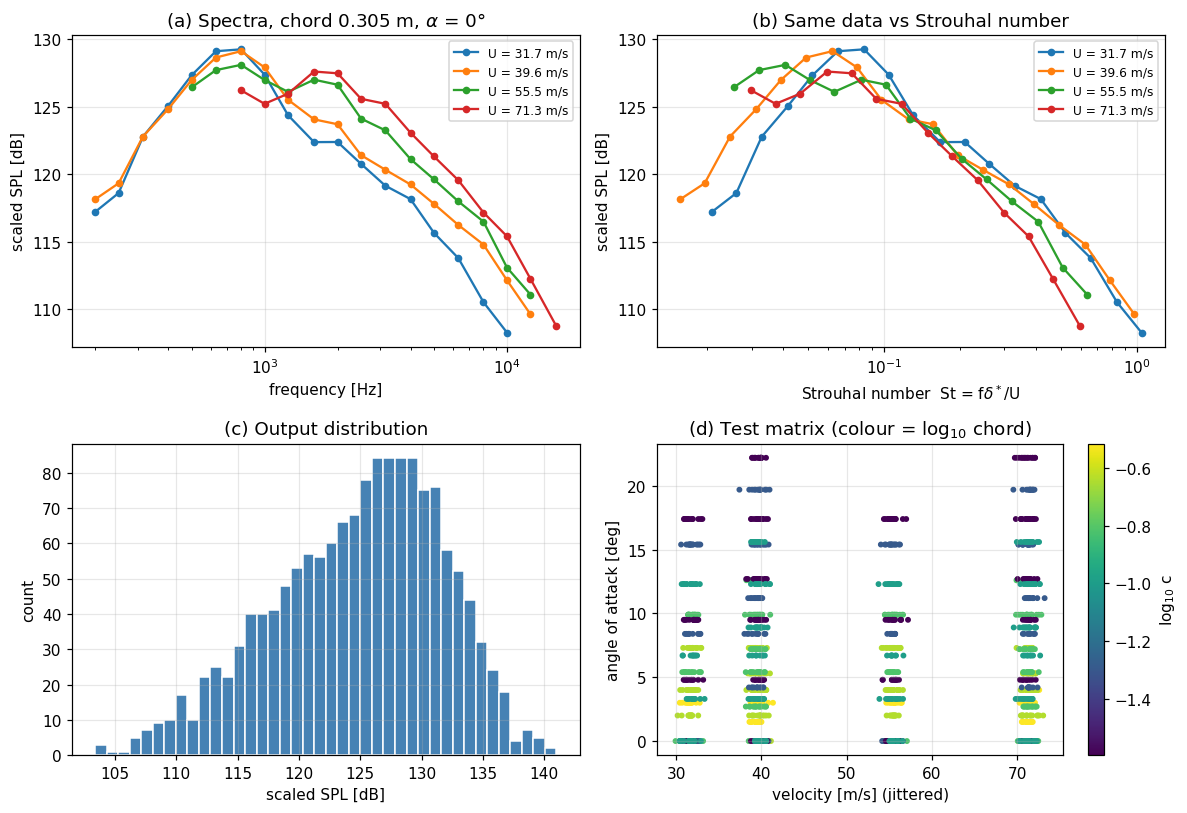

In [2]:
# ------------------------------------------------------------------
# Exploratory look at the data - ALWAYS do this before any modelling
# ------------------------------------------------------------------
fig, ax = plt.subplots(2, 2, figsize=(11, 7.5))

# (a) spectra for one chord at zero AoA, coloured by velocity
sub = df[(df.chord == 0.3048) & (df.aoa == 0.0)]
for u, g in sub.groupby("velocity"):
    ax[0, 0].semilogx(g.frequency, g.spl, "o-", ms=4, label=f"U = {u} m/s")
ax[0, 0].set(xlabel="frequency [Hz]", ylabel="scaled SPL [dB]",
             title="(a) Spectra, chord 0.305 m, $\\alpha$ = 0°")
ax[0, 0].legend(fontsize=8)

# (b) same spectra vs Strouhal number St = f * delta_star / U -> they collapse!
for u, g in sub.groupby("velocity"):
    St = g.frequency * g.delta_star / u
    ax[0, 1].semilogx(St, g.spl, "o-", ms=4, label=f"U = {u} m/s")
ax[0, 1].set(xlabel="Strouhal number  St = f$\\delta^*$/U", ylabel="scaled SPL [dB]",
             title="(b) Same data vs Strouhal number")
ax[0, 1].legend(fontsize=8)

# (c) output distribution
ax[1, 0].hist(df.spl, bins=40, color="steelblue", edgecolor="w")
ax[1, 0].set(xlabel="scaled SPL [dB]", ylabel="count", title="(c) Output distribution")

# (d) inputs are a coarse grid - typical of designed experiments
sc = ax[1, 1].scatter(df.velocity + rng.normal(0, 0.6, len(df)), df.aoa,
                      c=np.log10(df.chord), s=8, cmap="viridis")
ax[1, 1].set(xlabel="velocity [m/s] (jittered)", ylabel="angle of attack [deg]",
             title="(d) Test matrix (colour = log$_{10}$ chord)")
plt.colorbar(sc, ax=ax[1, 1], label="log$_{10}$ c")
fig.tight_layout()
plt.show()

**What the exploration tells us** (this drives every modelling choice below):

* **(a)** Each operating condition gives a smooth, single-peaked 1/3-octave spectrum — SPL first rises then
  falls with frequency. Any model linear in $f$ is doomed to mediocrity.
* **(b)** Re-plotting against the **Strouhal number** $St = f\delta^*/U$ makes the four velocities collapse
  towards a single curve — dimensional analysis at work. The peak sits near $St \approx 0.05$. We will
  *identify* that peak with full uncertainty in §5 and compare it with NASA's own formula.
* **(c)** The output spans ~38 dB; residual scatter of a few dB is expected (turbulence is stochastic and
  1/3-octave levels are estimates from finite averaging time).
* **(d)** The inputs live on a coarse **designed grid** (6 chords × 4 speeds × a set of incidences), not random
  samples — typical of wind-tunnel campaigns and one more reason model uncertainty matters between grid points.

### Feature engineering and the train/test split

Physical quantities spanning decades ($f$: 200 Hz–20 kHz; $c$: 25–305 mm; $\delta^*$: 0.4–58 mm) and power-law
physics ($U^n$, $St^m$) both argue for **logarithmic features**: a power law $y \propto x^n$ becomes *linear* in
$\log x$. So we use $\mathbf{x} = [\log_{10} f,\; \alpha,\; \log_{10} c,\; \log_{10} U,\; \log_{10}\delta^*]$,
standardised to zero mean and unit variance (essential for sensible priors and kernels).

We hold out 25% of the data as a **test set** that no model sees during training. One honest caveat: rows from
the *same* spectrum (same airfoil/condition, neighbouring frequency bands) end up on both sides of a random
split, so test scores are slightly optimistic about performance on a *brand-new* airfoil. Exercise 6 in §10
asks you to redo the split by whole configurations — grouped splits are the professional habit.

In [3]:
# ------------------------------------------------------------------
# Features (log-transformed), standardisation, train/test split
# ------------------------------------------------------------------
feature_names = ["log10 f", "AoA", "log10 c", "log10 U", "log10 d*"]
X = np.column_stack([np.log10(df.frequency), df.aoa, np.log10(df.chord),
                     np.log10(df.velocity), np.log10(df.delta_star)])
y = df.spl.values

idx = rng.permutation(len(df))
n_train = int(0.75 * len(df))
tr, te = idx[:n_train], idx[n_train:]

x_mean, x_std = X[tr].mean(axis=0), X[tr].std(axis=0)   # fit scaler on TRAIN only
Xtr, Xte = (X[tr] - x_mean) / x_std, (X[te] - x_mean) / x_std
ytr, yte = y[tr], y[te]
print(f"train: {len(ytr)}   test: {len(yte)}")

train: 1127   test: 376


## 3. A deterministic baseline: ordinary least squares

Model the output as a linear combination of features plus noise,
$y_i = \mathbf{w}^\mathsf{T}\boldsymbol{\phi}(\mathbf{x}_i) + \varepsilon_i$, with
$\boldsymbol{\phi}(\mathbf{x}) = [1, x_1, \dots, x_5]^\mathsf{T}$. Least squares minimises
$\sum_i \big(y_i - \mathbf{w}^\mathsf{T}\boldsymbol{\phi}_i\big)^2$, giving the **normal equations**

$$\hat{\mathbf{w}}_{\mathrm{LS}} = \big(\boldsymbol{\Phi}^\mathsf{T}\boldsymbol{\Phi}\big)^{-1}\boldsymbol{\Phi}^\mathsf{T}\mathbf{y},$$

where $\boldsymbol{\Phi}$ stacks the $\boldsymbol{\phi}_i^\mathsf{T}$ row-wise (Bishop, 2006, eq. 3.15). We score it with
three standard **deterministic error metrics** (formal definitions and discussion in §7):
mean absolute error (MAE), root-mean-square error (RMSE) and the coefficient of determination $R^2$.

OLS on the held-out test set:
  MAE  =  3.71 dB
  RMSE =  4.74 dB
  R^2  = 0.557


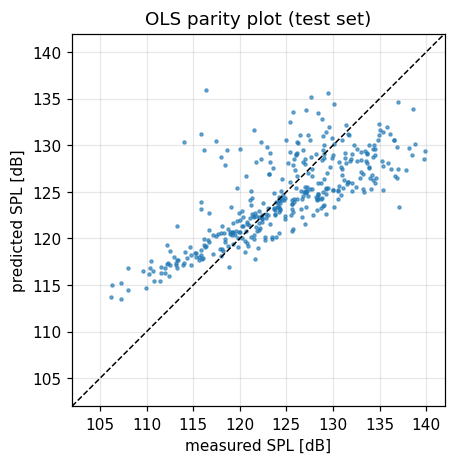

In [4]:
# ------------------------------------------------------------------
# Ordinary least squares via the normal equations
# ------------------------------------------------------------------
def design(Xs):                                   # phi(x): bias + features
    return np.column_stack([np.ones(len(Xs)), Xs])

Phi_tr, Phi_te = design(Xtr), design(Xte)
w_ls, *_ = np.linalg.lstsq(Phi_tr, ytr, rcond=None)
pred_ols = Phi_te @ w_ls

def mae(y, m):  return np.mean(np.abs(y - m))
def rmse(y, m): return np.sqrt(np.mean((y - m) ** 2))
def r2(y, m):   return 1 - np.sum((y - m) ** 2) / np.sum((y - np.mean(y)) ** 2)

print("OLS on the held-out test set:")
print(f"  MAE  = {mae(yte, pred_ols):5.2f} dB")
print(f"  RMSE = {rmse(yte, pred_ols):5.2f} dB")
print(f"  R^2  = {r2(yte, pred_ols):5.3f}")

fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.plot(yte, pred_ols, ".", ms=4, alpha=0.6)
lims = [102, 142]
ax.plot(lims, lims, "k--", lw=1)
ax.set(xlim=lims, ylim=lims, xlabel="measured SPL [dB]",
       ylabel="predicted SPL [dB]", title="OLS parity plot (test set)")
ax.set_aspect("equal")
plt.show()

RMSE ≈ 4.7 dB and $R^2 \approx 0.56$: the linear model captures broad trends but misses the curved spectral
shape completely (panel (a) above was visibly non-monotonic in $\log f$).

More fundamentally, ask the OLS model two engineering questions and watch it fail:

1. *"Your prediction is 126 dB — how sure are you?"* → silence. There is no error bar.
2. *"Is the chord coefficient really negative, or is that a fluke of this sample?"* → silence again.

Both questions are answered, exactly and cheaply, by making the same linear model **Bayesian**.

## 4. Bayesian linear regression: the same model, with honest uncertainty

Keep the linear model but treat noise and weights probabilistically (Bishop, 2006, §3.3):

* **Likelihood** (Gaussian noise with precision $\beta = 1/\sigma^2$):
  $\;p(\mathbf{y}\mid\mathbf{w}) = \prod_i \mathcal{N}\!\big(y_i \,\big|\, \mathbf{w}^\mathsf{T}\boldsymbol{\phi}_i,\; \beta^{-1}\big)$
* **Prior** (zero-mean isotropic Gaussian, precision $\alpha$):
  $\;p(\mathbf{w}) = \mathcal{N}\!\big(\mathbf{w}\,\big|\,\mathbf{0},\; \alpha^{-1}\mathbf{I}\big)$ — Bishop eq. (3.52)

Because everything is Gaussian, Bayes' rule gives the posterior **in closed form** — no sampling needed:

$$p(\mathbf{w}\mid\mathbf{y}) = \mathcal{N}(\mathbf{w}\mid \mathbf{m}_N, \mathbf{S}_N), \qquad
\mathbf{m}_N = \beta\, \mathbf{S}_N \boldsymbol{\Phi}^\mathsf{T}\mathbf{y}, \qquad
\mathbf{S}_N^{-1} = \alpha\mathbf{I} + \beta\, \boldsymbol{\Phi}^\mathsf{T}\boldsymbol{\Phi}$$

(Bishop eqs. 3.53–3.54). The **posterior predictive distribution** at a new input $\mathbf{x}_*$ is also Gaussian:

$$p(y_*\mid\mathbf{y}) = \mathcal{N}\!\big(y_* \,\big|\, \mathbf{m}_N^\mathsf{T}\boldsymbol{\phi}_*,\; \sigma_N^2(\mathbf{x}_*)\big),
\qquad
\sigma_N^2(\mathbf{x}_*) = \underbrace{\tfrac{1}{\beta}}_{\text{aleatoric}} \;+\; \underbrace{\boldsymbol{\phi}_*^\mathsf{T}\mathbf{S}_N\boldsymbol{\phi}_*}_{\text{epistemic}}$$

(Bishop eqs. 3.58–3.59). Note how the two uncertainty sources of §1 appear as *separate, interpretable terms*.

**Where do $\alpha$ and $\beta$ come from?** Rather than guessing, we maximise the marginal likelihood
("evidence") — *empirical Bayes*, Bishop §3.5.2 — iterating

$$\gamma = \sum_j \frac{\lambda_j}{\alpha + \lambda_j}, \qquad
\alpha \leftarrow \frac{\gamma}{\mathbf{m}_N^\mathsf{T}\mathbf{m}_N}, \qquad
\frac{1}{\beta} \leftarrow \frac{1}{N-\gamma}\sum_i \big(y_i - \mathbf{m}_N^\mathsf{T}\boldsymbol{\phi}_i\big)^2$$

(Bishop eqs. 3.91, 3.92, 3.95; $\lambda_j$ = eigenvalues of $\beta\boldsymbol{\Phi}^\mathsf{T}\boldsymbol{\Phi}$).
The quantity $\gamma$ is the **effective number of parameters** the data can support — a built-in guard against
overfitting that OLS simply does not have.

In [5]:
# ------------------------------------------------------------------
# Bayesian linear regression with evidence-maximised alpha, beta
# (Bishop 2006, eqs. 3.53-3.54, 3.58-3.59, 3.91-3.95)
# ------------------------------------------------------------------
def bayesian_linear_regression(Phi, t, n_iter=200, tol=1e-9):
    alpha, beta = 1e-3, 1.0                       # crude initial guesses
    eig0 = np.linalg.eigvalsh(Phi.T @ Phi)        # eigenvalues of Phi^T Phi
    for _ in range(n_iter):
        A = alpha * np.eye(Phi.shape[1]) + beta * Phi.T @ Phi   # S_N^-1
        mN = beta * np.linalg.solve(A, Phi.T @ t)               # eq. 3.53
        lam = beta * eig0
        gamma = np.sum(lam / (alpha + lam))                     # eq. 3.91
        alpha_new = gamma / (mN @ mN)                           # eq. 3.92
        beta_new = (len(t) - gamma) / np.sum((t - Phi @ mN)**2) # eq. 3.95
        if abs(alpha_new - alpha) < tol and abs(beta_new - beta) < tol:
            break
        alpha, beta = alpha_new, beta_new
    SN = np.linalg.inv(alpha * np.eye(Phi.shape[1]) + beta * Phi.T @ Phi)
    return mN, SN, alpha, beta, gamma

t_mean = ytr.mean()                                # centre target -> prior mean 0 is sensible
mN, SN, alpha, beta, gamma = bayesian_linear_regression(Phi_tr, ytr - t_mean)

pred_blr = Phi_te @ mN + t_mean                                   # predictive mean
var_blr = 1/beta + np.einsum("ij,jk,ik->i", Phi_te, SN, Phi_te)   # eq. 3.59
std_blr = np.sqrt(var_blr)

print(f"evidence-optimised:  alpha = {alpha:.3g}   beta = {beta:.3g} "
      f"(noise sd = {1/np.sqrt(beta):.2f} dB)")
print(f"effective number of parameters gamma = {gamma:.2f} of {Phi_tr.shape[1]}")
print(f"test RMSE = {rmse(yte, pred_blr):.2f} dB (essentially = OLS, as expected: "
      "same model class, plenty of data)")

evidence-optimised:  alpha = 0.194   beta = 0.0369 (noise sd = 5.21 dB)
effective number of parameters gamma = 5.82 of 6
test RMSE = 4.75 dB (essentially = OLS, as expected: same model class, plenty of data)


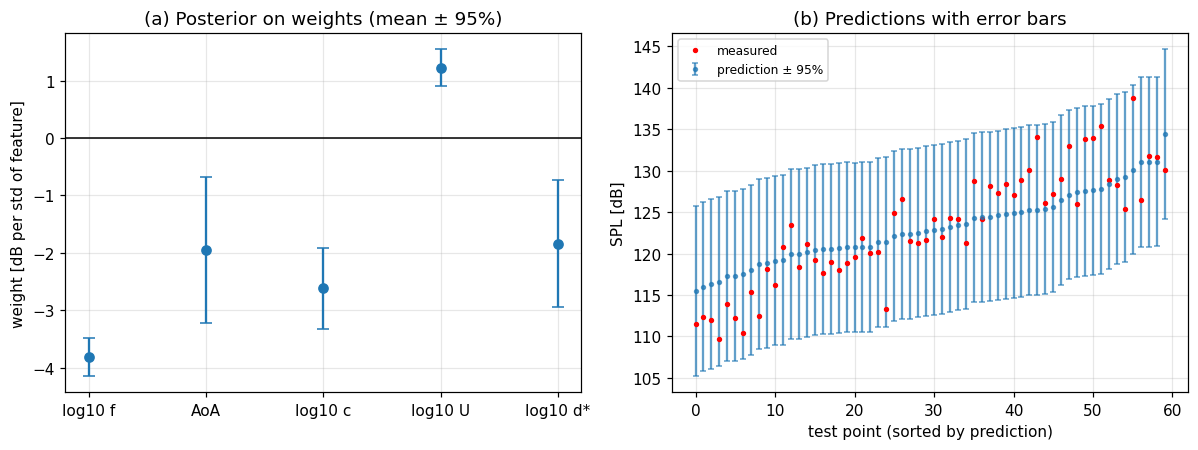

fraction of test points inside the 95% interval: 0.968 (should be near 0.95 if uncertainties are honest)


In [6]:
# ------------------------------------------------------------------
# What did we gain? 1) posteriors on coefficients  2) predictive intervals
# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) coefficient posteriors (standardised features -> comparable magnitudes)
sd_w = np.sqrt(np.diag(SN))[1:]
ax[0].errorbar(range(5), mN[1:], yerr=1.96 * sd_w, fmt="o", capsize=4)
ax[0].axhline(0, color="k", lw=1)
ax[0].set_xticks(range(5), feature_names)
ax[0].set(ylabel="weight [dB per std of feature]",
          title="(a) Posterior on weights (mean ± 95%)")

# (b) 60 random test points, sorted, with 95% predictive intervals
k = np.sort(rng.choice(len(yte), 60, replace=False))
order = np.argsort(pred_blr[k])
xx = np.arange(60)
ax[1].errorbar(xx, pred_blr[k][order], yerr=1.96 * std_blr[k][order],
               fmt=".", ms=5, alpha=0.7, capsize=2, label="prediction ± 95%")
ax[1].plot(xx, yte[k][order], "r.", ms=5, label="measured")
ax[1].set(xlabel="test point (sorted by prediction)", ylabel="SPL [dB]",
          title="(b) Predictions with error bars")
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

inside = np.abs(yte - pred_blr) < 1.96 * std_blr
print(f"fraction of test points inside the 95% interval: {inside.mean():.3f} "
      "(should be near 0.95 if uncertainties are honest)")

**Reading the posteriors like an engineer:**

* Panel (a): with standardised features the weights are directly comparable. Frequency is the strongest
  driver (negative: past the spectral peak, higher bands are quieter), then velocity (*positive but modest* —
  remember the $U^5$ scaling was already removed from the target). Note the **wide error bars on
  $\log_{10} c$ and $\log_{10}\delta^*$**: these two features are strongly correlated with each other and with
  $\alpha$ (thicker boundary layers on larger, more loaded airfoils), so the data cannot fully disentangle
  them. OLS would have shown you the same point estimates with no warning.
* Panel (b): roughly 95% of measured values do fall inside the 95% intervals — the model *knows how wrong it is*.
  That property is called **calibration** and we will measure it properly in §7.

But the intervals are wide (~±10 dB) because the *model class* is too rigid — a straight line through curved
physics. The Bayesian machinery is honest about the resulting error, but honesty is not accuracy. Two routes forward:

* put **physics** into the model structure and identify its parameters (§5), or
* let the data choose a **flexible nonparametric** model (§6).

## 5. Identification with Baysian Model Updating - MCMC: finding the spectral peak

### 5.1 The physics

Aeroacoustic theory gives sharp, testable structure. The classical velocity scalings for radiated intensity are
$U^8$ for free-jet turbulence (Lighthill, 1952), $U^6$ for compact surfaces (Curle, 1955) and
$\;U^5$ for turbulence scattered at an edge (Ffowcs Williams & Hall, 1970) — the trailing-edge case.
Beyond amplitude, the *spectral shape* collapses on the Strouhal number
$St = f\delta^*/U$ (we saw this in §2, panel b). RP-1218 models the 1/3-octave TBL-TE spectrum as a universal
shape function that is **symmetric in $\log_{10}(St/St_{\mathrm{peak}})$** (RP-1218 §5.1, Fig. 78), with the
peak location approximated by the semi-empirical fit

$$\boxed{St_1 = 0.02\, M^{-0.6}}$$

(RP-1218, §5.1.1 and eq. 32 region; verified against the report). For our condition below ($U = 71.3$ m/s,
$M \approx 0.209$) this predicts $St_1 \approx 0.051$.

### 5.2 Our identification problem

Take **one measured spectrum** (chord 0.305 m, $U = 71.3$ m/s, $\alpha = 0°$, 14 bands) and identify the peak by
fitting the simplest shape consistent with RP-1218's symmetry observation — a parabola in $\log_{10} St$:

$$\mathrm{SPL}(St) = L_{\mathrm{pk}} - a\,\big(\log_{10} St - \log_{10} St_{\mathrm{pk}}\big)^2 + \varepsilon,
\qquad \varepsilon \sim \mathcal{N}(0, \sigma^2)$$

Parameters $\boldsymbol{\theta} = (L_{\mathrm{pk}},\, a,\, \log_{10}St_{\mathrm{pk}},\, \log\sigma)$, with weakly
informative Gaussian priors (wide enough to be honest, proper enough to be stable). The question we will answer
probabilistically: **does our identified $St_{\mathrm{pk}}$ agree with NASA's $St_1 = 0.02M^{-0.6}$?**

### 5.3 Why MCMC, and how Metropolis–Hastings works

Unlike §4 there is no conjugate magic here (the model is nonlinear in $St_{\mathrm{pk}}$, and $\sigma$ is unknown),
so the posterior has no closed form. **Markov chain Monte Carlo** draws samples from any posterior you can
evaluate up to a constant. The **Metropolis–Hastings** algorithm (Metropolis et al., 1953; Hastings, 1970):

1. start at $\boldsymbol{\theta}^{(0)}$; repeat for $t = 1, 2, \dots$:
2. propose $\boldsymbol{\theta}' = \boldsymbol{\theta}^{(t-1)} + $ random step (we use a correlated Gaussian step);
3. accept with probability $\;A = \min\!\Big(1,\; \frac{p(\boldsymbol{\theta}'\mid\mathcal{D})}{p(\boldsymbol{\theta}^{(t-1)}\mid\mathcal{D})}\Big)$
   (valid for symmetric proposals); otherwise stay put.

The chain's stationary distribution is exactly the posterior (Gelman et al., 2013, ch. 11). Two practical
essentials that beginners often skip:

* **Proposal tuning.** A naive isotropic step mixes terribly when parameters are correlated. We first find the
  posterior mode (MAP) and the local curvature (Hessian $\mathbf{H}$), i.e. a **Laplace approximation**
  $\mathcal{N}(\boldsymbol{\theta}_{\mathrm{MAP}}, \mathbf{H}^{-1})$ (Bishop §4.4; MacKay 2003, ch. 27), then
  propose with covariance $\propto \mathbf{H}^{-1}$. Aim for acceptance ≈ 20–50%.
* **Diagnostics.** Discard burn-in, look at trace plots (should look like "fuzzy caterpillars"), and check the
  acceptance rate — *never* trust a single chain blindly.

14 bands;  M = 0.209;  BPM formula predicts St_1 = 0.0511


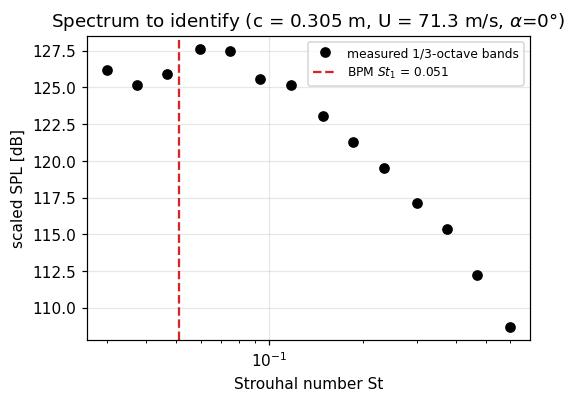

In [7]:
# ------------------------------------------------------------------
# Select one measured spectrum and set up the log-posterior
# ------------------------------------------------------------------
C0 = 340.5                                # speed of sound [m/s]; matches Mach values in RP-1218
g = df[(df.chord == 0.3048) & (df.velocity == 71.3) & (df.aoa == 0.0)]
St_dat = (g.frequency * g.delta_star / g.velocity).values
spl_dat = g.spl.values
M = 71.3 / C0
St1_bpm = 0.02 * M ** -0.6                # NASA RP-1218 semi-empirical peak Strouhal
print(f"{len(g)} bands;  M = {M:.3f};  BPM formula predicts St_1 = {St1_bpm:.4f}")

def spectrum_model(theta, St):
    L_pk, a, log_St_pk = theta[0], theta[1], theta[2]
    return L_pk - a * (np.log10(St) - log_St_pk) ** 2

def log_posterior(theta):
    L_pk, a, log_St_pk, log_sig = theta
    if a <= 0:                                        # curvature must be positive
        return -np.inf
    sig = np.exp(log_sig)
    resid = spl_dat - spectrum_model(theta, St_dat)
    log_lik = np.sum(-0.5*np.log(2*np.pi*sig**2) - 0.5*resid**2/sig**2)
    log_prior = (-0.5*(L_pk - 125)**2 / 15**2          # peak level ~ 125 +/- 15 dB
                 -0.5*(np.log(a) - np.log(10))**2/1.5**2   # curvature, log-scale prior
                 -0.5*(log_St_pk + 1.3)**2 / 1.0**2    # St_pk ~ 0.05, +/- 1 decade
                 -0.5*log_sig**2 / 1.5**2)             # sigma ~ 1 dB, very broad
    return log_lik + log_prior

# quick visual: the spectrum we are about to fit
fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.semilogx(St_dat, spl_dat, "ko", label="measured 1/3-octave bands")
ax.axvline(St1_bpm, color="tab:red", ls="--", label=f"BPM $St_1$ = {St1_bpm:.3f}")
ax.set(xlabel="Strouhal number St", ylabel="scaled SPL [dB]",
       title="Spectrum to identify (c = 0.305 m, U = 71.3 m/s, $\\alpha$=0°)")
ax.legend(fontsize=8)
plt.show()

In [8]:
# ------------------------------------------------------------------
# Step 1: MAP estimate + Laplace approximation (to build a good proposal)
# ------------------------------------------------------------------
theta0 = np.array([spl_dat.max(), 10.0,
                   np.log10(St_dat[np.argmax(spl_dat)]), 0.0])
opt = optimize.minimize(lambda t: -log_posterior(t), theta0, method="Nelder-Mead",
                        options={"maxiter": 20000, "xatol": 1e-10, "fatol": 1e-10})
theta_map = opt.x

def numerical_hessian(f, x, eps=1e-4):
    d = len(x)
    H = np.zeros((d, d))
    for i in range(d):
        for j in range(d):
            xpp = x.copy(); xpp[i] += eps; xpp[j] += eps
            xpm = x.copy(); xpm[i] += eps; xpm[j] -= eps
            xmp = x.copy(); xmp[i] -= eps; xmp[j] += eps
            xmm = x.copy(); xmm[i] -= eps; xmm[j] -= eps
            H[i, j] = (f(xpp) - f(xpm) - f(xmp) + f(xmm)) / (4 * eps**2)
    return H

H = numerical_hessian(lambda t: -log_posterior(t), theta_map)
Sigma_prop = np.linalg.inv(H)                       # Laplace covariance
L_chol = np.linalg.cholesky(Sigma_prop)

par_names = ["L_pk [dB]", "a [dB/dec^2]", "log10 St_pk", "log sigma"]
print("MAP estimate and Laplace standard deviations:")
for nm, m_, s_ in zip(par_names, theta_map, np.sqrt(np.diag(Sigma_prop))):
    print(f"  {nm:14s} = {m_:8.3f}  +/- {s_:.3f}")
print(f"  -> St_pk (MAP) = {10**theta_map[2]:.4f}")

MAP estimate and Laplace standard deviations:
  L_pk [dB]      =  126.711  +/- 0.229
  a [dB/dec^2]   =   16.426  +/- 1.134
  log10 St_pk    =   -1.273  +/- 0.030
  log sigma      =   -0.490  +/- 0.189
  -> St_pk (MAP) = 0.0533


acceptance rate = 0.51  (target roughly 0.2-0.5)


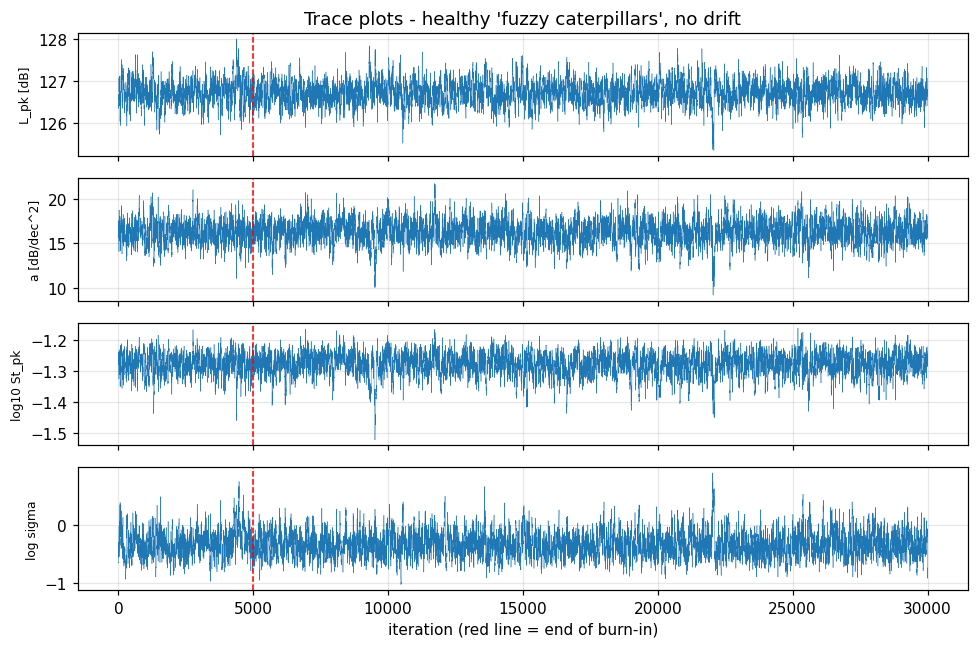

In [9]:
# ------------------------------------------------------------------
# Step 2: Metropolis-Hastings sampling
# ------------------------------------------------------------------
n_samples, scale = 30000, 0.8            # step scale ~0.8 x Laplace sd works well here
chain = np.zeros((n_samples, 4))
theta, lp = theta_map.copy(), log_posterior(theta_map)
n_accept = 0
for i in range(n_samples):
    proposal = theta + scale * L_chol @ rng.standard_normal(4)   # correlated step
    lp_prop = log_posterior(proposal)
    if np.log(rng.random()) < lp_prop - lp:                      # MH accept rule
        theta, lp = proposal, lp_prop
        n_accept += 1
    chain[i] = theta

burn = 5000
post = chain[burn:]
print(f"acceptance rate = {n_accept/n_samples:.2f}  (target roughly 0.2-0.5)")

fig, ax = plt.subplots(4, 1, figsize=(9, 6), sharex=True)
for j in range(4):
    ax[j].plot(chain[:, j], lw=0.3)
    ax[j].axvline(burn, color="r", ls="--", lw=1)
    ax[j].set_ylabel(par_names[j], fontsize=8)
ax[-1].set_xlabel("iteration (red line = end of burn-in)")
ax[0].set_title("Trace plots - healthy 'fuzzy caterpillars', no drift")
fig.tight_layout()
plt.show()

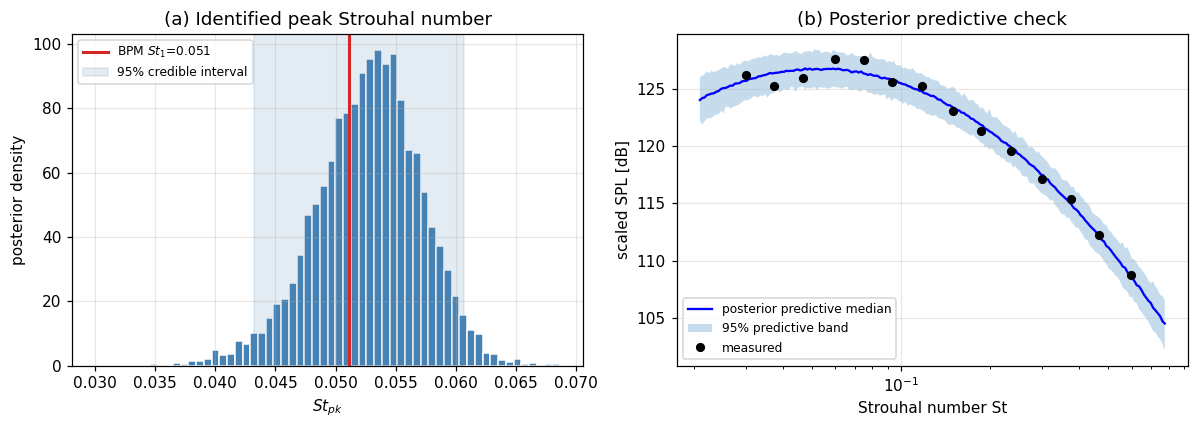

St_pk posterior mean = 0.0527,  95% CI = [0.0432, 0.0607]
NASA RP-1218 formula St_1 = 0.02 M^-0.6 = 0.0511  -> inside the 95% CI: True
P(St_pk within +/-20% of the BPM value) = 0.97
identified noise level sigma = 0.73 dB


In [10]:
# ------------------------------------------------------------------
# Step 3: the payoff - posterior on the peak Strouhal number vs NASA's formula
# ------------------------------------------------------------------
St_pk_post = 10 ** post[:, 2]
ci = np.percentile(St_pk_post, [2.5, 97.5])
p_within_20pc = np.mean((St_pk_post > 0.8*St1_bpm) & (St_pk_post < 1.2*St1_bpm))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(St_pk_post, bins=60, density=True, color="steelblue", edgecolor="w")
ax[0].axvline(St1_bpm, color="tab:red", lw=2, label=f"BPM $St_1$={St1_bpm:.3f}")
ax[0].axvspan(*ci, alpha=0.15, color="steelblue", label="95% credible interval")
ax[0].set(xlabel="$St_{pk}$", ylabel="posterior density",
          title="(a) Identified peak Strouhal number")
ax[0].legend(fontsize=8)

# posterior predictive: push parameter samples through the model
St_grid = np.logspace(np.log10(St_dat.min()*0.7), np.log10(St_dat.max()*1.3), 200)
draws = np.array([spectrum_model(post[k], St_grid)
                  + np.exp(post[k, 3]) * rng.standard_normal(len(St_grid))
                  for k in rng.choice(len(post), 400, replace=False)])
lo, mid, hi = np.percentile(draws, [2.5, 50, 97.5], axis=0)
ax[1].semilogx(St_grid, mid, "b-", lw=1.5, label="posterior predictive median")
ax[1].fill_between(St_grid, lo, hi, alpha=0.25, label="95% predictive band")
ax[1].semilogx(St_dat, spl_dat, "ko", ms=5, label="measured")
ax[1].set(xlabel="Strouhal number St", ylabel="scaled SPL [dB]",
          title="(b) Posterior predictive check")
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"St_pk posterior mean = {St_pk_post.mean():.4f},  95% CI = [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"NASA RP-1218 formula St_1 = 0.02 M^-0.6 = {St1_bpm:.4f}"
      f"  -> inside the 95% CI: {ci[0] < St1_bpm < ci[1]}")
print(f"P(St_pk within +/-20% of the BPM value) = {p_within_20pc:.2f}")
print(f"identified noise level sigma = {np.exp(post[:,3]).mean():.2f} dB")

22 of 24 conditions give a well-constrained peak (the rest have the peak at the edge of the measured frequency range - reported, not hidden)


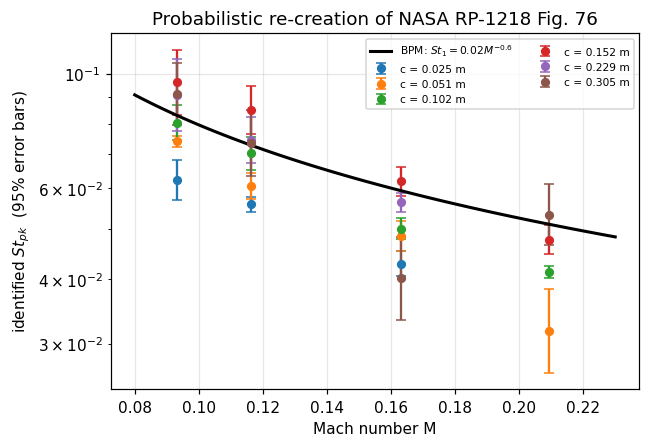

In [11]:
# ------------------------------------------------------------------
# Scaling up: repeat the fit (MAP + Laplace, the fast approximation) for
# ALL zero-incidence spectra -> a probabilistic version of RP-1218 Fig. 76
# ------------------------------------------------------------------
results = []
for (c_, u_), gg in df[df.aoa == 0.0].groupby(["chord", "velocity"]):
    St_ = (gg.frequency * gg.delta_star / u_).values
    spl_ = gg.spl.values
    def lp_cond(t, St_=St_, spl_=spl_):
        if t[1] <= 0:
            return -np.inf
        sig = np.exp(t[3])
        resid = spl_ - (t[0] - t[1] * (np.log10(St_) - t[2]) ** 2)
        return (np.sum(-0.5*np.log(2*np.pi*sig**2) - 0.5*resid**2/sig**2)
                - 0.5*(t[0]-125)**2/15**2 - 0.5*(np.log(t[1])-np.log(10))**2/1.5**2
                - 0.5*(t[2]+1.3)**2/1.0**2 - 0.5*t[3]**2/1.5**2)
    x0_ = np.array([spl_.max(), 10.0, np.log10(St_[np.argmax(spl_)]), 0.0])
    r_ = optimize.minimize(lambda t: -lp_cond(t), x0_, method="Nelder-Mead",
                           options={"maxiter": 20000})
    sd_ = np.sqrt(np.diag(np.linalg.inv(
        numerical_hessian(lambda t: -lp_cond(t), r_.x))))
    results.append((c_, u_ / C0, 10 ** r_.x[2], sd_[2]))

res = pd.DataFrame(results, columns=["chord", "M", "St_pk", "sd_log10St"])
reliable = res.sd_log10St < 0.1          # drop fits whose peak is outside the measured band
print(f"{reliable.sum()} of {len(res)} conditions give a well-constrained peak "
      "(the rest have the peak at the edge of the measured frequency range - reported, not hidden)")

fig, ax = plt.subplots(figsize=(6.2, 4.2))
for c_, grp in res[reliable].groupby("chord"):
    lo_err = grp.St_pk * (1 - 10**(-1.96*grp.sd_log10St))
    hi_err = grp.St_pk * (10**(1.96*grp.sd_log10St) - 1)
    ax.errorbar(grp.M, grp.St_pk, yerr=[lo_err, hi_err], fmt="o", ms=5,
                capsize=3, label=f"c = {c_:.3f} m")
M_grid = np.linspace(0.08, 0.23, 100)
ax.plot(M_grid, 0.02 * M_grid**-0.6, "k-", lw=2, label="BPM: $St_1 = 0.02M^{-0.6}$")
ax.set(xlabel="Mach number M", ylabel="identified $St_{pk}$  (95% error bars)",
       yscale="log", title="Probabilistic re-creation of NASA RP-1218 Fig. 76")
ax.legend(fontsize=7, ncol=2)
plt.show()

**What just happened is the essence of probabilistic system identification:**

* From 14 noisy data points, MCMC delivered a *full posterior* for the peak Strouhal number. NASA's
  semi-empirical value $St_1 = 0.051$ lies **inside our 95% credible interval** — two independent routes
  (their 1989 hand-scaling of dozens of spectra; our Bayesian fit of one) agree, which is exactly the kind of
  cross-validation against literature you should demand of any identification result.
* The identified measurement noise ($\sigma \approx 0.7$ dB) is a *result*, not an assumption — we learned the
  aleatoric uncertainty from the data.
* Batch-fitting all 24 zero-incidence conditions reproduces the trend *and the scatter* of the report's own
  figure: the identified peaks track $0.02M^{-0.6}$ with deviations at small chords/high speed, where the peak
  leaves the measured band (the fits that "know they don't know" get large error bars — exactly as they should).
* **Model discrepancy caveat:** our parabola is an approximation of RP-1218's true shape function A, so
  $\sigma$ absorbs both measurement noise *and* structural model error. Distinguishing the two rigorously is
  the calibration framework of Kennedy & O'Hagan (2001) — the standard reference when you calibrate CFD or
  acoustic prediction codes against test data.

This model is superbly interpretable but only describes *one spectrum shape at a time*.
For a model of the **whole dataset** — every chord, speed and incidence — we go nonparametric.

## 6. Gaussian process regression: distributions over functions

A **Gaussian process** (GP) is a prior directly on the function $f(\mathbf{x})$: any finite set of function
values is jointly Gaussian, $f \sim \mathcal{GP}\big(0,\, k(\mathbf{x}, \mathbf{x}')\big)$, fully specified by a
covariance **kernel** $k$ (Rasmussen & Williams, 2006, ch. 2). We use the squared-exponential (RBF) kernel with
**automatic relevance determination** (ARD) — one lengthscale $\ell_d$ per input (R&W §5.1, eq. 5.1):

$$k(\mathbf{x}, \mathbf{x}') = \sigma_f^2 \exp\!\Big(-\tfrac{1}{2}\sum_{d=1}^{D} \frac{(x_d - x_d')^2}{\ell_d^2}\Big)$$

With Gaussian observation noise $\sigma_n^2$, the posterior predictive at test inputs $X_*$ is again exactly Gaussian:

$$\bar{\mathbf{f}}_* = K_*^\mathsf{T}\big(K + \sigma_n^2 I\big)^{-1}\mathbf{y}
\qquad\qquad
\mathrm{cov}(\mathbf{f}_*) = K_{**} - K_*^\mathsf{T}\big(K + \sigma_n^2 I\big)^{-1}K_*$$

(R&W eqs. 2.25 and 2.26). Hyperparameters $(\sigma_f, \boldsymbol{\ell}, \sigma_n)$ are chosen by maximising the
**log marginal likelihood**

$$\log p(\mathbf{y}\mid X) = -\tfrac{1}{2}\mathbf{y}^\mathsf{T}(K + \sigma_n^2 I)^{-1}\mathbf{y}
- \tfrac{1}{2}\log\big|K + \sigma_n^2 I\big| - \tfrac{N}{2}\log 2\pi$$

(R&W eq. 2.30) — the same evidence idea as §4, and again with a built-in complexity penalty (the
$\log\det$ term). Interpretability bonus: a *large* $\ell_d$ means the function barely varies along input $d$,
so **ARD lengthscales are a data-driven relevance ranking of your inputs**.

To demystify the equations we first implement a GP **from scratch** on a single spectrum (1 input), then use
scikit-learn for the full 5-input model. Watch two things in the 1D plot: the band *between* points
(interpolation) and *beyond* the last training point (extrapolation).

optimised hyperparameters: signal sd = 4.93 dB, lengthscale = 0.44 decades of f, noise sd = 0.66 dB


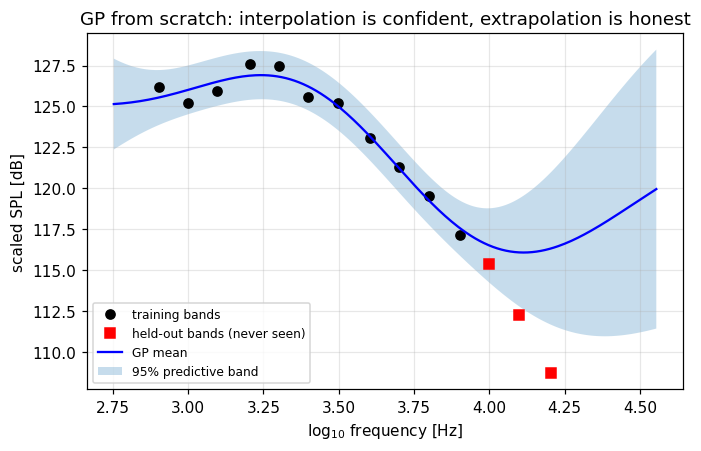

In [12]:
# ------------------------------------------------------------------
# GP from scratch in 1D: SPL vs log10(frequency) for the Section-5 spectrum.
# Train on all but the last 3 bands -> watch extrapolation uncertainty grow.
# ------------------------------------------------------------------
x1 = np.log10(g.frequency.values)         # 1D input
y1 = spl_dat
x1_tr, y1_tr = x1[:-3], y1[:-3]           # hold out the 3 highest bands
y1_mu = y1_tr.mean()

def rbf(xa, xb, sf, ell):
    return sf**2 * np.exp(-0.5 * (xa[:, None] - xb[None, :])**2 / ell**2)

def neg_log_marglik(log_th):              # R&W eq. 2.30 (negated)
    sf, ell, sn = np.exp(log_th)
    K = rbf(x1_tr, x1_tr, sf, ell) + sn**2 * np.eye(len(x1_tr))
    Lc = np.linalg.cholesky(K)
    a_ = np.linalg.solve(Lc.T, np.linalg.solve(Lc, y1_tr - y1_mu))
    return (0.5*(y1_tr - y1_mu) @ a_ + np.log(np.diag(Lc)).sum()
            + 0.5*len(x1_tr)*np.log(2*np.pi))

opt1 = optimize.minimize(neg_log_marglik, np.log([3.0, 0.3, 0.5]), method="L-BFGS-B")
sf, ell, sn = np.exp(opt1.x)
print(f"optimised hyperparameters: signal sd = {sf:.2f} dB, lengthscale = {ell:.2f} "
      f"decades of f, noise sd = {sn:.2f} dB")

# predictive equations, R&W eqs. 2.25-2.26
xs = np.linspace(x1.min()-0.15, x1.max()+0.35, 250)
K = rbf(x1_tr, x1_tr, sf, ell) + sn**2 * np.eye(len(x1_tr))
Ks = rbf(x1_tr, xs, sf, ell)
Kss = rbf(xs, xs, sf, ell)
Kinv_y = np.linalg.solve(K, y1_tr - y1_mu)
mu_s = y1_mu + Ks.T @ Kinv_y                                  # eq. 2.25
cov_s = Kss - Ks.T @ np.linalg.solve(K, Ks)                   # eq. 2.26
sd_s = np.sqrt(np.clip(np.diag(cov_s), 0, None) + sn**2)      # + noise -> predictive

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(x1_tr, y1_tr, "ko", label="training bands")
ax.plot(x1[-3:], y1[-3:], "rs", label="held-out bands (never seen)")
ax.plot(xs, mu_s, "b-", lw=1.5, label="GP mean")
ax.fill_between(xs, mu_s - 1.96*sd_s, mu_s + 1.96*sd_s, alpha=0.25,
                label="95% predictive band")
ax.set(xlabel="log$_{10}$ frequency [Hz]", ylabel="scaled SPL [dB]",
       title="GP from scratch: interpolation is confident, extrapolation is honest")
ax.legend(fontsize=8)
plt.show()

The band is narrow where training data exist and balloons beyond the last training point — but look
closely at the held-out bands: the nearest one falls inside the 95% interval, while the two farthest drop
*below* it.

The RBF kernel knows nothing about spectral roll-off physics, so in extrapolation it pulls the
mean back toward the average while the real spectrum keeps falling; the uncertainty grows in the right
direction, just not fast enough. Two honest lessons every practitioner eventually learns the hard way:

* **GPs are superb interpolators, but extrapolation quality is set by the kernel's assumptions, not by the
  data.** (A kernel encoding "levels decay at high $St$" — or the model of §5, which nailed
  the roll-off — would do better out here. Kernels *are* modelling hypotheses; see Exercise 2.)
* The widening band is still doing its job: it *flags* the extrapolation region, and its assessment ("I am
  ~3× less certain out here") is roughly right even where the mean is biased. In a design loop that flag is
  the actionable output — it tells the optimiser or the test engineer to get data (or physics) there before
  trusting the number.

That self-flagging behaviour is what makes GPs the workhorse of surrogate modelling in turbomachinery design.

Now the full problem: all five inputs, the whole test matrix. We use scikit-learn
(`GaussianProcessRegressor`), which implements exactly the equations above. To keep the notebook fast we train
on a random subset of 500 points — cubic $\mathcal{O}(N^3)$ cost is the GP's main weakness (R&W ch. 8;
sparse/inducing-point approximations fix this at scale). Training on all 1127 points takes a few minutes and
improves test RMSE further (≈1.2 dB); try it as an exercise.

In [13]:
# ------------------------------------------------------------------
# Full 5-input ARD Gaussian process with scikit-learn
# ------------------------------------------------------------------
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

n_sub = 500
sub = rng.choice(len(Xtr), n_sub, replace=False)

kernel = ConstantKernel(1.0) * RBF(length_scale=np.ones(5)) + WhiteKernel(0.05)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True,
                              n_restarts_optimizer=1, random_state=0)
gp.fit(Xtr[sub], ytr[sub])
pred_gp, std_gp = gp.predict(Xte, return_std=True)

print("optimised kernel:", gp.kernel_, "\n")
ard = gp.kernel_.k1.k2.length_scale
rank = np.argsort(ard)
print("ARD relevance ranking (short lengthscale = more relevant):")
for r_ in rank:
    print(f"  {feature_names[r_]:9s}  lengthscale = {ard[r_]:.2f}")
print(f"\ntest RMSE = {rmse(yte, pred_gp):.2f} dB   R^2 = {r2(yte, pred_gp):.3f}"
      f"   (OLS/BLR were ~{rmse(yte, pred_ols):.1f} dB)")

optimised kernel: 0.984**2 * RBF(length_scale=[0.58, 0.918, 0.728, 2.5, 1.02]) + WhiteKernel(noise_level=0.0215) 

ARD relevance ranking (short lengthscale = more relevant):
  log10 f    lengthscale = 0.58
  log10 c    lengthscale = 0.73
  AoA        lengthscale = 0.92
  log10 d*   lengthscale = 1.02
  log10 U    lengthscale = 2.50

test RMSE = 1.77 dB   R^2 = 0.938   (OLS/BLR were ~4.7 dB)


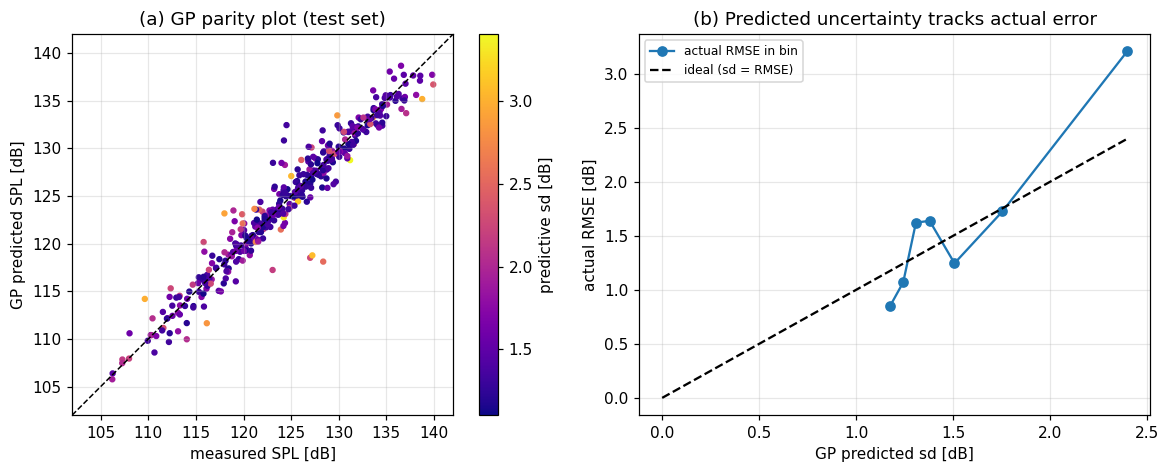

In [14]:
# ------------------------------------------------------------------
# Does the GP KNOW where it is wrong? Parity plot + uncertainty-vs-error
# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))

sc = ax[0].scatter(yte, pred_gp, c=std_gp, s=10, cmap="plasma")
lims = [102, 142]
ax[0].plot(lims, lims, "k--", lw=1)
ax[0].set(xlim=lims, ylim=lims, xlabel="measured SPL [dB]",
          ylabel="GP predicted SPL [dB]", title="(a) GP parity plot (test set)")
plt.colorbar(sc, ax=ax[0], label="predictive sd [dB]")
ax[0].set_aspect("equal")

# bin test points by predicted sd; compare with actual error in each bin
bins = np.quantile(std_gp, np.linspace(0, 1, 8))
centers, actual = [], []
for lo_, hi_ in zip(bins[:-1], bins[1:]):
    m_ = (std_gp >= lo_) & (std_gp <= hi_)
    centers.append(std_gp[m_].mean())
    actual.append(rmse(yte[m_], pred_gp[m_]))
ax[1].plot(centers, actual, "o-", label="actual RMSE in bin")
ax[1].plot([0, max(centers)], [0, max(centers)], "k--", label="ideal (sd = RMSE)")
ax[1].set(xlabel="GP predicted sd [dB]", ylabel="actual RMSE [dB]",
          title="(b) Predicted uncertainty tracks actual error")
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

Three observations worth internalising:

* **Accuracy:** RMSE drops from ≈5 dB (linear) to well under 2 dB — the GP has learned the curved spectral
  shapes and their interactions with geometry, from data alone.
* **Self-awareness:** panel (b) shows the predicted standard deviation *tracks the actual error* — points the
  GP flags as uncertain really are harder. This is the property that makes probabilistic predictions
  *actionable* (§8).
* **ARD tells a physics story:** the shortest lengthscale (most relevant input) is $\log_{10} f$ — of course,
  we are describing spectra. And the *longest* lengthscale is $\log_{10} U$: the GP has discovered from data
  that the target barely depends on velocity — because, as we learned in §2, the $U^5$ scaling was already
  divided out by the dataset's authors. **A purely statistical model just rediscovered the fifth-power
  trailing-edge law's absence** — a lovely example of ML and physics cross-checking each other.

## 7. Error metrics: judging deterministic *and* probabilistic quality

A probabilistic model must be judged on **two axes**: how close its central predictions are (accuracy), and
whether its claimed uncertainties are trustworthy (calibration/sharpness). Reporting RMSE alone silently
discards half of what you paid for.

**Deterministic metrics** (predictions $\hat y_i$, measurements $y_i$, $N$ test points):

| Metric | Formula | Notes |
|---|---|---|
| MAE | $\frac{1}{N}\sum \lvert y_i - \hat y_i\rvert$ | robust to outliers; same units as $y$ (dB) |
| RMSE | $\sqrt{\frac{1}{N}\sum (y_i - \hat y_i)^2}$ | penalises large errors; same units as $y$ |
| $R^2$ | $1 - \frac{\sum(y_i - \hat y_i)^2}{\sum(y_i - \bar y)^2}$ | fraction of variance explained; 1 = perfect, 0 = "predict the mean" |
| NMSE | $\frac{100}{N \sigma_y^2}\sum(y_i - \hat y_i)^2$ | normalised %, common in the sysID literature |

**Probabilistic metrics** (predictive distribution $\mathcal{N}(\mu_i, \sigma_i^2)$ per test point):

* **NLPD** (negative log predictive density) — a *proper scoring rule* (Gneiting & Raftery, 2007): it cannot be
  gamed; both over- and under-confidence are punished. For Gaussian predictions:
  $$\mathrm{NLPD} = \frac{1}{N}\sum_{i=1}^N \Big[\tfrac{1}{2}\log(2\pi\sigma_i^2) + \frac{(y_i - \mu_i)^2}{2\sigma_i^2}\Big]$$
  (lower is better; used as the standard GP benchmark metric, R&W §2.5).
* **PICP / coverage** — the fraction of test targets inside the nominal $(1-\alpha)$ central interval,
  e.g. $\mu_i \pm 1.96\sigma_i$ for 95%. Should match the nominal level.
* **Calibration curve** — coverage plotted for *all* nominal levels $p \in (0,1)$; a well-calibrated model hugs
  the diagonal (Kuleshov et al., 2018). Above the diagonal = under-confident (intervals too wide), below =
  over-confident (dangerous!).
* **Sharpness** — the average predictive standard deviation. Among *calibrated* models, sharper is better;
  sharpness without calibration is a lie.

In [15]:
# ------------------------------------------------------------------
# Metric implementations + the model comparison table
# ------------------------------------------------------------------
def nmse(y, m):
    return 100 * np.mean((y - m) ** 2) / np.var(y)

def nlpd(y, mu, sd):
    return np.mean(0.5*np.log(2*np.pi*sd**2) + 0.5*(y - mu)**2 / sd**2)

def picp(y, mu, sd, level=0.95):
    z = stats.norm.ppf(0.5 + level/2)
    return np.mean(np.abs(y - mu) < z * sd)

# give OLS a plug-in constant sigma (the MLE of the residual sd) so it can
# be scored probabilistically too - this is what "deterministic + error bar
# from residuals" amounts to
sd_ols = np.full(len(yte), rmse(ytr, Phi_tr @ w_ls))

models = {
    "OLS (+plug-in sd)": (pred_ols, sd_ols),
    "Bayesian LR":       (pred_blr, std_blr),
    "GP (ARD)":          (pred_gp,  std_gp),
}
rows = []
for name, (mu_, sd_) in models.items():
    rows.append([mae(yte, mu_), rmse(yte, mu_), r2(yte, mu_), nmse(yte, mu_),
                 nlpd(yte, mu_, sd_), picp(yte, mu_, sd_, 0.95),
                 picp(yte, mu_, sd_, 0.50), sd_.mean()])
table = pd.DataFrame(rows, index=models.keys(),
                     columns=["MAE [dB]", "RMSE [dB]", "R^2", "NMSE [%]",
                              "NLPD", "PICP 95%", "PICP 50%", "sharpness [dB]"])
table.round(3)

,MAE [dB],RMSE [dB],R^2,NMSE [%],NLPD,PICP 95%,PICP 50%,sharpness [dB]
OLS (+plug-in sd),3.709,4.741,0.557,44.318,2.983,0.968,0.537,5.194
Bayesian LR,3.717,4.747,0.556,44.428,2.985,0.968,0.540,5.221
GP (ARD),1.175,1.773,0.938,6.200,1.863,0.944,0.572,1.538


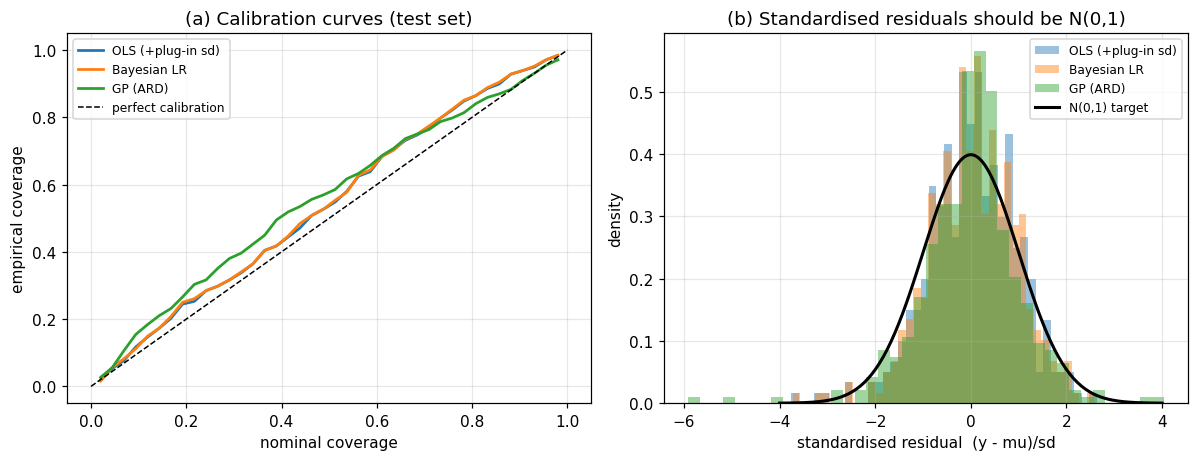

In [16]:
# ------------------------------------------------------------------
# Calibration curves + standardised residuals
# ------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))

levels = np.linspace(0.02, 0.98, 40)
for name, (mu_, sd_) in models.items():
    emp = [picp(yte, mu_, sd_, p) for p in levels]
    ax[0].plot(levels, emp, lw=1.8, label=name)
ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
ax[0].set(xlabel="nominal coverage", ylabel="empirical coverage",
          title="(a) Calibration curves (test set)")
ax[0].legend(fontsize=8)

zz = np.linspace(-4, 4, 200)
for name, (mu_, sd_) in models.items():
    ax[1].hist((yte - mu_) / sd_, bins=40, density=True, alpha=0.45, label=name)
ax[1].plot(zz, stats.norm.pdf(zz), "k-", lw=2, label="N(0,1) target")
ax[1].set(xlabel="standardised residual  (y - mu)/sd", ylabel="density",
          title="(b) Standardised residuals should be N(0,1)")
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

**How to read the table and the curves — the punchlines of this notebook:**

* On **accuracy** (MAE/RMSE/$R^2$/NMSE) the GP wins by a factor of ~3. No surprise: flexible model, smooth physics.
* On **calibration**, *all three* models sit near the diagonal and pass the 95%-coverage check — including
  boring old OLS with a constant plug-in error bar. Lesson: **calibration alone is easy; calibration *and*
  sharpness is the achievement.** Look at the sharpness column: the GP's intervals are ~3× tighter *while
  remaining calibrated*, and its NLPD (the metric that scores both axes at once) is by far the best.
* NLPD is the single number to quote if you must choose one; it is a proper scoring rule, so a model cannot
  improve it by bluffing (Gneiting & Raftery, 2007).
* The standardised-residual histogram is the quick diagnostic you will actually use day-to-day: if
  $(y-\mu)/\sigma$ is not roughly $\mathcal{N}(0,1)$, your predictive variances are broken (too wide → spike
  near zero; too narrow → heavy tails).

## 8. From posteriors to engineering decisions

Uncertainty is only useful if it changes what you *do*. Two worked examples with the GP model:

**(1) Probabilistic limit compliance.** Suppose a (hypothetical) certification-style requirement says the
scaled band level at some operating conditions must not exceed $L_{\max} = 128$ dB. A Gaussian predictive
distribution turns straight into an exceedance probability:

$$P(\mathrm{SPL} > L_{\max}) = 1 - \Phi\!\Big(\frac{L_{\max} - \mu}{\sigma}\Big)$$

A deterministic model can only compare $\hat y \lessgtr 128$; near the limit, that coin-flip becomes a
warranty claim. With probabilities you can adopt a risk policy: **accept** if $P < 5\%$, **reject** if
$P > 95\%$, otherwise **test** — spending wind-tunnel money only where the model is genuinely unsure.

**(2) Where to test next.** The predictive standard deviation is a map of the model's ignorance: the next
tunnel entry should target the conditions with the largest $\sigma$ (this is the core idea of *active
learning* and Bayesian optimisation, the standard tools of modern surrogate-based design).

Risk-based screening against L_max = 128.0 dB over 376 conditions:
accept        201
needs test     90
reject         85

Deterministic thresholding hides 90 genuinely ambiguous conditions (24% of the test set) - the probabilistic model sends exactly these to the tunnel.


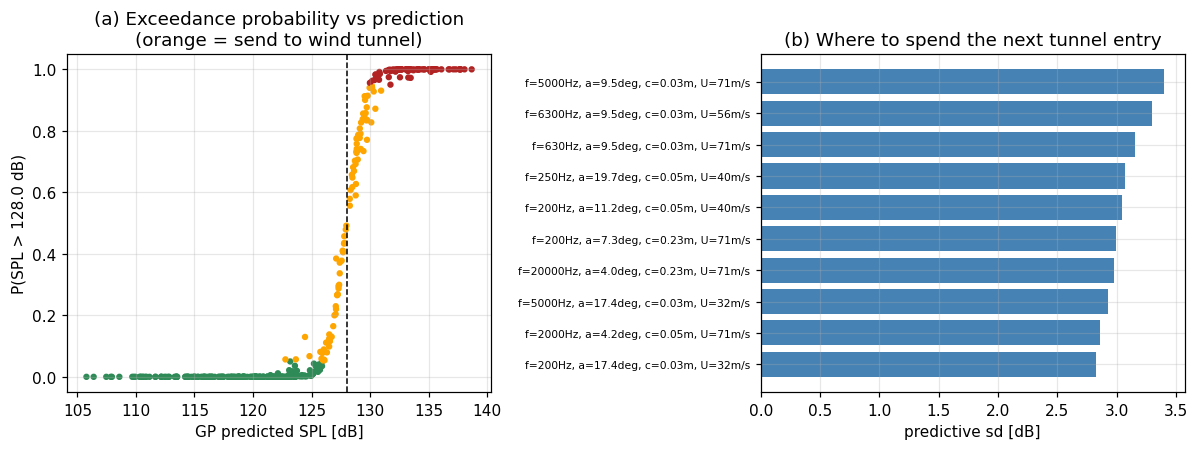

In [17]:
# ------------------------------------------------------------------
# Decision analysis on the test set
# ------------------------------------------------------------------
L_max = 128.0
p_exceed = 1 - stats.norm.cdf(L_max, loc=pred_gp, scale=std_gp)

decision = np.where(p_exceed < 0.05, "accept",
            np.where(p_exceed > 0.95, "reject", "needs test"))
counts = pd.Series(decision).value_counts()
print(f"Risk-based screening against L_max = {L_max} dB over {len(yte)} conditions:")
print(counts.to_string())

# how many of the deterministic pass/fail calls would the probability flag as unsafe?
det_call = pred_gp > L_max
ambiguous = (p_exceed > 0.05) & (p_exceed < 0.95)
print(f"\nDeterministic thresholding hides {ambiguous.sum()} genuinely ambiguous "
      f"conditions ({100*ambiguous.mean():.0f}% of the test set) - the probabilistic "
      "model sends exactly these to the tunnel.")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].scatter(pred_gp, p_exceed, c=np.where(ambiguous, "orange",
              np.where(det_call, "firebrick", "seagreen")), s=10)
ax[0].axvline(L_max, color="k", ls="--", lw=1)
ax[0].set(xlabel="GP predicted SPL [dB]", ylabel=f"P(SPL > {L_max} dB)",
          title="(a) Exceedance probability vs prediction\n(orange = send to wind tunnel)")

# where to test next: top-10 most uncertain test conditions
top = np.argsort(std_gp)[::-1][:10]
info = df.iloc[te[top]][["frequency", "aoa", "chord", "velocity"]].copy()
info["pred sd [dB]"] = std_gp[top].round(2)
ax[1].barh(range(10), std_gp[top][::-1], color="steelblue")
ax[1].set_yticks(range(10),
                 [f"f={r.frequency:.0f}Hz, a={r.aoa:.1f}deg, c={r.chord:.2f}m, U={r.velocity:.0f}m/s"
                  for r in info.iloc[::-1].itertuples()], fontsize=7)
ax[1].set(xlabel="predictive sd [dB]", title="(b) Where to spend the next tunnel entry")
fig.tight_layout()
plt.show()

## 9. How these strategies are used in practice

Everything in this notebook is a scaled-down version of workflows used daily in industry and research:

* **Surrogate-based turbomachinery design.** GP ("kriging") surrogates trained on a few dozen expensive CFD
  runs or rig tests drive compressor/turbine blade optimisation; the predictive variance powers *expected
  improvement* acquisition (Bayesian optimisation), so the optimiser samples exactly where it is uncertain —
  the textbook treatment is Forrester, Sóbester & Keane (2008).
* **Calibration of prediction codes.** When CFD/aeroacoustic codes are tuned against test data, the modern
  framework is Bayesian calibration with explicit *model discrepancy* (Kennedy & O'Hagan, 2001) — exactly the
  issue we met with our parabola in §5. Data-driven, uncertainty-aware turbulence-model augmentation is
  reviewed by Duraisamy, Iaccarino & Xiao (2019).
* **The BPM model itself is deployed engineering practice.** Semi-empirical laws identified from this very
  dataset power wind-turbine noise codes such as NREL's NAFNoise/OpenFAST aeroacoustics module
  (Moriarty & Migliore, 2003) — when you fit and validate models on these data, you are retracing the
  construction of tools still used for siting and certification today.
* **Structural health & operational monitoring.** GP-based models that separate operating-condition effects
  from damage indicators are used for wind-turbine monitoring (Avendaño-Valencia, Chatzi & Tcherniak, 2020);
  GP latent force models perform joint input–state–parameter estimation on operating structures
  (Rogers, Worden & Cross, 2020). The same NLPD/coverage metrics you computed in §7 are the standard
  evidence that such systems are trustworthy.
* **Benchmark heritage.** This dataset (donated to UCI by R. López) appears in hundreds of ML papers, so you
  can directly compare your RMSE against published methods — a rare luxury with engineering data.

**What the results of *this* notebook would be used for:** the §5 posterior validates/updates a semi-empirical
constant with honest error bars (feeding better noise codes); the §6 GP is a drop-in surrogate for blade-section
noise in a design loop; the §8 exceedance probabilities and "test-next" ranking are the direct interface to
certification risk management and test planning.

## 10. Equation provenance and references

Every key equation above, verified against its source:

| Equation | Used in | Source (eq. number) |
|---|---|---|
| Normal equations $\hat{\mathbf{w}} = (\Phi^\mathsf{T}\Phi)^{-1}\Phi^\mathsf{T}\mathbf{y}$ | §3 | Bishop (2006) eq. 3.15 |
| BLR posterior $\mathbf{m}_N, \mathbf{S}_N$ | §4 | Bishop (2006) eqs. 3.53–3.54 |
| BLR predictive mean/variance | §4 | Bishop (2006) eqs. 3.58–3.59 |
| Evidence updates $\gamma, \alpha, \beta$ | §4 | Bishop (2006) eqs. 3.91, 3.92, 3.95 |
| MH acceptance rule | §5 | Metropolis et al. (1953); Hastings (1970); Gelman et al. (2013) ch. 11 |
| Laplace approximation | §5 | Bishop (2006) §4.4; MacKay (2003) ch. 27 |
| Edge-noise $U^5$ intensity scaling | §2, §5 | Ffowcs Williams & Hall (1970); cf. RP-1218 eq. (17) |
| Scaled SPL $= \mathrm{SPL} - 10\log_{10}(\delta^* M^5 L \bar D_h/r_e^2)$ | §2 | Brooks, Pope & Marcolini (1989) §5.1 |
| Peak Strouhal $St_1 = 0.02M^{-0.6}$; $St = f\delta^*/U$ | §5 | Brooks, Pope & Marcolini (1989) §5.1.1 |
| GP predictive mean/covariance | §6 | Rasmussen & Williams (2006) eqs. 2.25–2.26 |
| GP log marginal likelihood | §6 | Rasmussen & Williams (2006) eq. 2.30 |
| ARD (SE) kernel | §6 | Rasmussen & Williams (2006) §5.1, eq. 5.1 |
| NLPD as proper scoring rule | §7 | Gneiting & Raftery (2007); R&W (2006) §2.5 |
| Calibration curves for regression | §7 | Kuleshov, Fenner & Ermon (2018) |

### References

1. Brooks, T.F., Pope, D.S. & Marcolini, M.A. (1989). *Airfoil Self-Noise and Prediction*. NASA Reference
   Publication 1218. https://ntrs.nasa.gov/citations/19890016302
2. Dua, D. & Graff, C. (2019). *UCI Machine Learning Repository* — Airfoil Self-Noise Data Set.
   https://archive.ics.uci.edu/ml/datasets/Airfoil+Self-Noise
3. Lighthill, M.J. (1952). On sound generated aerodynamically. I. General theory. *Proc. R. Soc. Lond. A*,
   211(1107), 564–587.
4. Curle, N. (1955). The influence of solid boundaries upon aerodynamic sound. *Proc. R. Soc. Lond. A*,
   231(1187), 505–514.
5. Ffowcs Williams, J.E. & Hall, L.H. (1970). Aerodynamic sound generation by turbulent flow in the vicinity
   of a scattering half plane. *J. Fluid Mech.*, 40(4), 657–670.
6. Ljung, L. (1999). *System Identification: Theory for the User* (2nd ed.). Prentice Hall.
7. Bishop, C.M. (2006). *Pattern Recognition and Machine Learning*. Springer. (Ch. 3–4.)
8. Rasmussen, C.E. & Williams, C.K.I. (2006). *Gaussian Processes for Machine Learning*. MIT Press.
   Free online: http://gaussianprocess.org/gpml/
9. MacKay, D.J.C. (2003). *Information Theory, Inference, and Learning Algorithms*. CUP. (Ch. 27, 29.)
10. Metropolis, N., Rosenbluth, A.W., Rosenbluth, M.N., Teller, A.H. & Teller, E. (1953). Equation of state
    calculations by fast computing machines. *J. Chem. Phys.*, 21(6), 1087–1092.
11. Hastings, W.K. (1970). Monte Carlo sampling methods using Markov chains and their applications.
    *Biometrika*, 57(1), 97–109.
12. Gelman, A., Carlin, J.B., Stern, H.S., Dunson, D.B., Vehtari, A. & Rubin, D.B. (2013). *Bayesian Data
    Analysis* (3rd ed.). CRC Press.
13. Gneiting, T. & Raftery, A.E. (2007). Strictly proper scoring rules, prediction, and estimation.
    *J. Am. Stat. Assoc.*, 102(477), 359–378.
14. Kuleshov, V., Fenner, N. & Ermon, S. (2018). Accurate uncertainties for deep learning using calibrated
    regression. *ICML 2018*.
15. Kennedy, M.C. & O'Hagan, A. (2001). Bayesian calibration of computer models. *J. R. Stat. Soc. B*,
    63(3), 425–464.
16. Forrester, A.I.J., Sóbester, A. & Keane, A.J. (2008). *Engineering Design via Surrogate Modelling:
    A Practical Guide*. Wiley.
17. Moriarty, P. & Migliore, P. (2003). *Semi-Empirical Aeroacoustic Noise Prediction Code for Wind
    Turbines*. NREL/TP-500-34478.
18. Duraisamy, K., Iaccarino, G. & Xiao, H. (2019). Turbulence modeling in the age of data.
    *Annu. Rev. Fluid Mech.*, 51, 357–377.
19. Avendaño-Valencia, L.D., Chatzi, E.N. & Tcherniak, D. (2020). Gaussian process models for mitigation of
    operational variability in the structural health monitoring of wind turbines.
    *Mech. Syst. Signal Process.*, 142, 106686.
20. Rogers, T.J., Worden, K. & Cross, E.J. (2020). On the application of Gaussian process latent force
    models for joint input–state–parameter estimation. *Mech. Syst. Signal Process.*, 140, 106580.

## Summary, limitations, and exercises

**You have now run the complete probabilistic system-identification workflow on real wind-tunnel data:**
explore → baseline → exact Bayesian inference (BLR) → sampling-based inference for a model
(MCMC, validated against a NASA semi-empirical law) → nonparametric Bayesian regression (GP) → two-axis metric
assessment (accuracy *and* calibration) → risk-based decisions.

**Honest limitations to remember** (each is an opportunity, see exercises):
random splitting leaks neighbouring bands of the same spectrum between train and test; all likelihoods were
homoscedastic Gaussians; the §5 parabola is an approximation of the true spectral shape (model discrepancy);
the GP was subsampled for speed; and the dataset's *scaled* target means amplitude physics was partly
pre-applied by the original authors.

Addtional on limitations worth noting:

The principal problem is the random train/test split.
The dataset contains only 106 distinct spectra or operating configurations. Each spectrum contains several frequency bands. Under the notebook's current split:
1.	All 376 test rows come from spectra that are already represented in the training set.
2.	All 103 test configurations overlap with training configurations.
Therefore, the reported GP result (RMSE about 1.77 dB and R-squared about 0.94) measures interpolation of missing frequency bands from already-seen configurations. It does not measure prediction for a new chord, velocity, and angle combination.
The notebook acknowledges this in its limitations, but grouped validation should be part of the main analysis rather than an exercise. Consider usinge a split grouped by:
["aoa", "chord", "velocity", "delta_star"]

3.	The MCMC prior on curvature is parameterized inconsistently. If log(a) has a Gaussian prior while sampling a, the log-density needs the Jacobian term -log(a). A cleaner solution is to sample log_a directly.
4.	The numerical Hessian should be checked for positive definiteness before Cholesky decomposition.
5.	One MCMC chain plus an acceptance rate and trace plot is insufficient to establish convergence. Add multiple chains, R-hat, effective sample size, and Monte Carlo standard errors.
6.	ARD lengthscales indicate variation scales, but should not be presented as causal variable importance, especially because the inputs are correlated.
7.	The exceedance example uses scaled SPL, not an absolute certification level. It is valid pedagogically but should remain clearly labelled hypothetical.


### Exercises

1. **Full-data GP.** Train on all 1127 points (allow a few minutes). How much do RMSE and NLPD improve? Then
   read about sparse GPs (R&W ch. 8) and explain how you would scale to $10^6$ points.
2. **Kernels as hypotheses.** Swap the RBF for a Matérn-5/2 kernel (`sklearn.gaussian_process.kernels.Matern`).
   Compare NLPD. Which smoothness assumption do 1/3-octave spectra actually support?
3. **Priors matter (or do they?).** In §5, halve and double all prior standard deviations and rerun the MCMC.
   How sensitive is the $St_{\mathrm{pk}}$ posterior? Why is it so robust here? (Hint: 14 data points vs how
   many parameters?)
4. **Heteroscedastic noise.** The residual scatter looks larger at high $St$. Extend the §5 model with
   $\sigma(St) = \sigma_0 (St/St_{\mathrm{pk}})^{\gamma}$ and identify $\gamma$. Does NLPD on held-out bands improve?
5. **Convergence diagnostics.** Run 4 MCMC chains from dispersed starting points and compute the Gelman–Rubin
   $\hat R$ statistic (Gelman et al., 2013, §11.4). What value indicates convergence?
6. **Grouped validation.** Re-split the data leaving out *entire configurations* (all bands of a given
   chord/velocity/AoA). How much do the §7 metrics degrade, and which model degrades most gracefully? This is
   the honest estimate of performance on a new airfoil.